# Análise Exploratória de Dados (EDA)

Aplicar EDA no dataset **Telco Customer Churn** para entender a distribuição das variáveis, identificar padrões entre features e preparar os dados para modelagem preditiva de churn.

#### Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configurações do Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Configurações do Seaborn
sns.set_theme(style='whitegrid', palette='muted')

#### Configuração de variaveis globais

In [2]:
# Configurações centralizadas
DATA_PATH = '../data/raw/telco_customer_churn.xlsx'
SHEET_NAME = 'Telco_Churn'
TARGET_COL = 'Churn Value'

# Colunas excluídas da análise de features:
# identificadores, metadados geográficos e variáveis com leakage do target
EXCLUDE_COLS = [
    'CustomerID', 'Count',
    'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
    'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason',
]

# Cardinalidade máxima para incluir uma categórica nos gráficos
MAX_CAT_CARDINALITY = 10

# Labels legíveis para as classes do target (Churn)
CLASS_LABELS = {0: 'Não Churn', 1: 'Churn'}
CLASS_COLORS = {0: 'steelblue', 1: 'coral'}

#### Leitura do dataset

In [3]:
# Leitura do dataset
df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
print(f"Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

Dataset carregado: 7,043 linhas × 33 colunas


In [4]:
# Lista acumuladora de insights — preenchida ao longo da EDA
insights = []

## Visão Geral do Dataset

Entendimento da estrutura dos dados, incluindo tipos de variáveis, valores nulos e estatísticas descritivas.

### Informações Gerais

In [5]:
print(f"Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas\n")

info = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notna().sum(),
    'null': df.isna().sum(),
    'unique': df.nunique(),
})
info['null_%'] = (info['null'] / len(df) * 100).round(2)
info

Shape: 7,043 linhas × 33 colunas



,dtype,non_null,null,unique,null_%
CustomerID,object,7043,0,7043,0.00
Count,int64,7043,0,1,0.00
Country,object,7043,0,1,0.00
State,object,7043,0,1,0.00
City,object,7043,0,1129,0.00
Zip Code,int64,7043,0,1652,0.00
Lat Long,object,7043,0,1652,0.00
Latitude,float64,7043,0,1652,0.00
Longitude,float64,7043,0,1651,0.00
Gender,object,7043,0,2,0.00


A única feature com alta nulidade é a 'Churn Reason', responsável por explicar o motivo do churn. Como o objetivo é prever churn, essa feature não será utilizada na modelagem.
Não trazendo impacto relevante para a modelagem, porém é uma informação importante para o negócio, pois pode ajudar a entender o motivo do churn e auxiliar na tomada de decisão.

In [6]:
print("=== Primeiras linhas ===")
df.head()

=== Primeiras linhas ===


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [7]:
print("=== Últimas linhas ===")
df.tail()

=== Últimas linhas ===


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.424926,-117.184503,Male,No,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No,0,38,5097,NaN


### Valores Nulos

              contagem  % do total
Churn Reason      5174       73.46


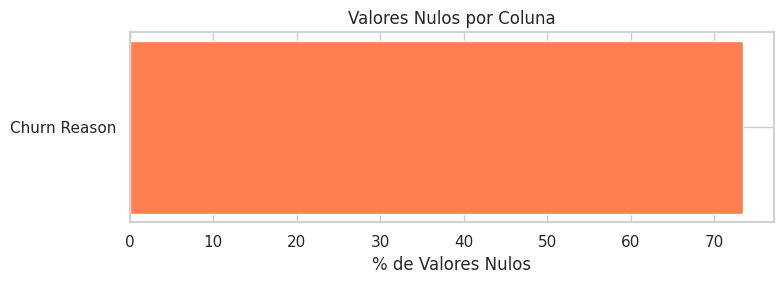

In [8]:
# Valores nulos
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

if missing.empty:
    print("Nenhum valor nulo detectado.")
else:
    result = pd.DataFrame({'contagem': missing, '% do total': missing_pct})
    print(result)

    fig, ax = plt.subplots(figsize=(8, max(3, len(missing) * 0.6)))
    ax.barh(missing_pct.index, missing_pct.values, color='coral', edgecolor='white')
    ax.set_xlabel('% de Valores Nulos')
    ax.set_title('Valores Nulos por Coluna')
    plt.tight_layout()
    plt.show()

### Detecção de Colunas com tipo Incorreto

In [9]:
# Detecção e conversão de colunas com tipo incorreto
# No pandas 3, StringDtype e object são dtypes separados.
# Usamos isinstance para cobrir ambos sem warnings.
conversion_log = []
text_cols = [c for c in df.columns
             if isinstance(df[c].dtype, pd.StringDtype) or df[c].dtype == object]

for col in text_cols:
    series = df[col]
    converted = pd.to_numeric(series, errors='coerce')
    n_valid = series.notna().sum()
    ratio = converted.notna().sum() / n_valid if n_valid > 0 else 0
    if ratio > 0.8:
        n_invalid = n_valid - converted.notna().sum()
        conversion_log.append({
            'coluna': col,
            'tipo_atual': str(series.dtype),
            'tipo_sugerido': 'float64',
            'valores_não_convertíveis': n_invalid,
        })
        df[col] = converted

if conversion_log:
    print("Colunas convertidas para numérico (valores inválidos → NaN):")
    print(pd.DataFrame(conversion_log).to_string(index=False))
else:
    print("Nenhuma conversão de tipo necessária.")

# ── Derivar conjuntos de colunas para o restante da EDA ─────────────────────
feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS + [TARGET_COL]]
num_cols = df[feature_cols].select_dtypes(include='number').columns.tolist()
cat_cols = [c for c in feature_cols
            if isinstance(df[c].dtype, pd.StringDtype) or df[c].dtype == object]

print(f"\nFeatures numéricas  ({len(num_cols)}): {num_cols}")
print(f"Features categóricas ({len(cat_cols)}): {cat_cols}")

Colunas convertidas para numérico (valores inválidos → NaN):
       coluna tipo_atual tipo_sugerido  valores_não_convertíveis
Total Charges     object       float64                        11

Features numéricas  (3): ['Tenure Months', 'Monthly Charges', 'Total Charges']
Features categóricas (16): ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


### Estatísticas Descritivas

In [10]:
print("=== Estatísticas descritivas — features numéricas ===")
df[num_cols].describe().T

=== Estatísticas descritivas — features numéricas ===


,count,mean,std,min,25%,50%,75%,max
Tenure Months,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
Monthly Charges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
Total Charges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


In [11]:
insights.extend([
    {
        'secao': 'Qualidade dos Dados',
        'insight': 'Total Charges com dtype incorreto (object): 11 valores em branco convertidos para NaN após pd.to_numeric()',
        'impacto_modelo': 'NaNs precisam de imputação antes do treinamento para evitar erro no sklearn',
        'acao_sugerida': 'Aplicar SimpleImputer(strategy="median") no pipeline de pré-processamento',
    },
    {
        'secao': 'Qualidade dos Dados',
        'insight': 'Churn Reason tem 73.5% de valores nulos (5.174 de 7.043 registros)',
        'impacto_modelo': 'Coluna de leakage (motivo só existe após o churn) — não pode ser usada como feature',
        'acao_sugerida': 'Manter excluída de EXCLUDE_COLS; pode ser útil para análise de negócio pós-predição',
    },
    {
        'secao': 'Qualidade dos Dados',
        'insight': 'Dataset final com 3 features numéricas e 16 categóricas após exclusão de metadados/leakage',
        'impacto_modelo': 'Dominância categórica exige encoding adequado (OneHotEncoder) e atenção à dimensionalidade',
        'acao_sugerida': 'Usar ColumnTransformer separando pipelines para numéricas e categóricas',
    },
])

## Análise da Variável Target (Churn)

Identificar desbalanceamento dos dados (*class imbalance*) da variável target. Em geral, o churn representa uma baixa proporção do dataset, o que pode impactar a performance do modelo preditivo.

Distribuição de 'Churn Value':
  Não Churn (0): 5,174 (73.5%)
  Churn (1): 1,869 (26.5%)


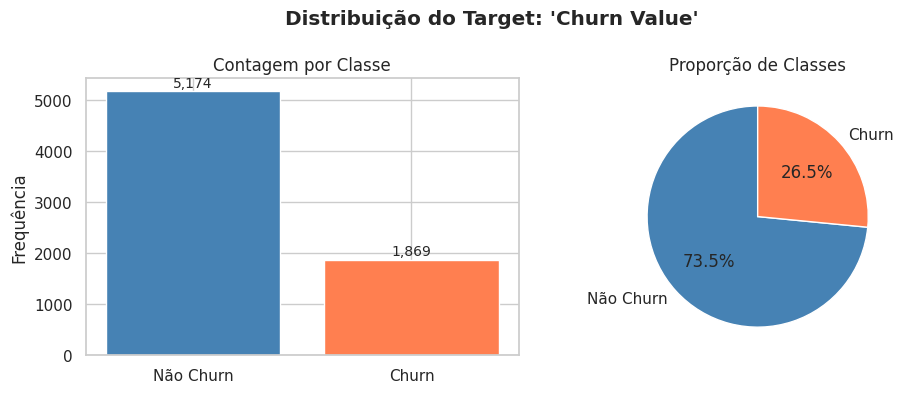

In [12]:
# Distribuição do target (Churn)
counts = df[TARGET_COL].value_counts().sort_index()
pct = (counts / counts.sum() * 100).round(1)

print(f"Distribuição de '{TARGET_COL}':")
for val, cnt in counts.items():
    print(f"  {CLASS_LABELS.get(val, val)} ({val}): {cnt:,} ({pct[val]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Barras
bars = axes[0].bar(
    [CLASS_LABELS.get(v, v) for v in counts.index],
    counts.values,
    color=[CLASS_COLORS.get(v, 'grey') for v in counts.index],
    edgecolor='white'
)
for bar, cnt in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=10)
axes[0].set_ylabel('Frequência')
axes[0].set_title('Contagem por Classe')

# Pizza
axes[1].pie(
    counts.values,
    labels=[CLASS_LABELS.get(v, v) for v in counts.index],
    autopct='%1.1f%%',
    colors=[CLASS_COLORS.get(v, 'grey') for v in counts.index],
    startangle=90
)
axes[1].set_title('Proporção de Classes')

plt.suptitle(f"Distribuição do Target: '{TARGET_COL}'", fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
ratio = counts.min() / counts.max()
print(f"Ratio de balanceamento (minoritária / majoritária): {ratio:.3f}")
if ratio < 0.5:
    print("⚠️  Desbalanceamento significativo detectado.")
    print("   Métricas recomendadas: AUC-ROC e F1-Score (classe churn).")
    print("   Estratégias possíveis: class_weight='balanced', SMOTE, ajuste de threshold.")
else:
    print("✓  Dataset razoavelmente balanceado.")

Ratio de balanceamento (minoritária / majoritária): 0.361
⚠️  Desbalanceamento significativo detectado.
   Métricas recomendadas: AUC-ROC e F1-Score (classe churn).
   Estratégias possíveis: class_weight='balanced', SMOTE, ajuste de threshold.


In [14]:
insights.extend([
    {
        'secao': 'Variável Target',
        'insight': 'Desbalanceamento: 26.5% churn (1.869) vs 73.5% não churn (5.174) — ratio 0.361',
        'impacto_modelo': 'Modelo trivial que prevê sempre "Não Churn" atingiria 73.5% de acurácia sem aprender nada',
        'acao_sugerida': 'Usar class_weight="balanced" ou SMOTE; avaliar com AUC-ROC e F1 (classe churn)',
    },
])

## Distribuição das Features Numéricas

Analisar a distribuição das features para identificar padrões e relações com a variável target. Histogramas e boxplots são utilizados para visualizar a distribuição das features numéricas, enquanto gráficos de barras são usados para features categóricas.

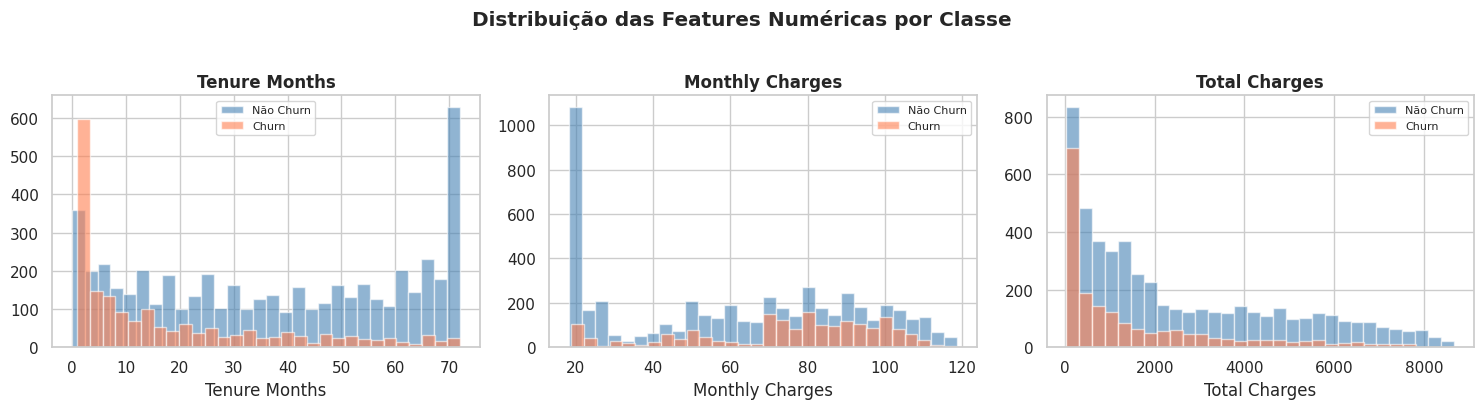

In [15]:
# Histogramas com overlay por classe
n = len(num_cols)
ncols = min(3, n)
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).ravel()

for i, col in enumerate(num_cols):
    for val, grp in df.groupby(TARGET_COL):
        axes[i].hist(
            grp[col].dropna(), bins=30, alpha=0.6,
            label=CLASS_LABELS.get(val, val),
            color=CLASS_COLORS.get(val, None)
        )
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].legend(fontsize=8)

for ax in axes[n:]:
    fig.delaxes(ax)

plt.suptitle('Distribuição das Features Numéricas por Classe', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

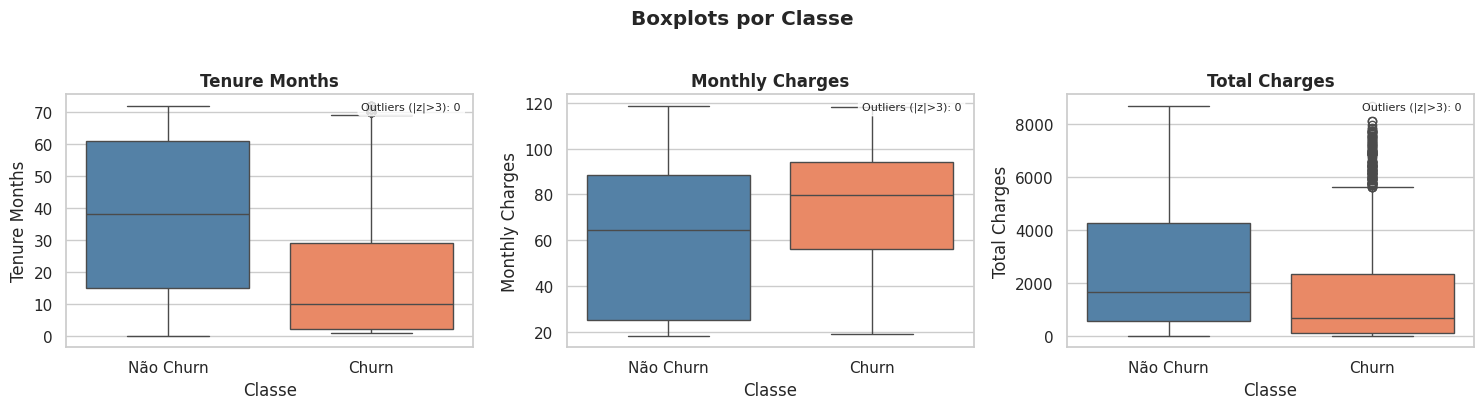

In [16]:
# Boxplots por classe com contagem de outliers
# Mapear target para labels string antes de passar ao seaborn
# evita conflitos de tipo entre chaves int do palette e valores str do eixo
df_box = df[num_cols + [TARGET_COL]].copy()
df_box['Classe'] = df_box[TARGET_COL].map(CLASS_LABELS)
class_order   = [CLASS_LABELS[v] for v in sorted(df[TARGET_COL].unique())]
class_palette = {CLASS_LABELS[k]: v for k, v in CLASS_COLORS.items()}

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).ravel()

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df_box, x='Classe', y=col, ax=axes[i],
        hue='Classe', palette=class_palette, legend=False,
        order=class_order
    )
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Classe')

    z = np.abs(stats.zscore(df[col].dropna()))
    n_outliers = (z > 3).sum()
    axes[i].annotate(
        f'Outliers (|z|>3): {n_outliers}',
        xy=(0.97, 0.97), xycoords='axes fraction',
        ha='right', va='top', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
    )

for ax in axes[n:]:
    fig.delaxes(ax)

plt.suptitle('Boxplots por Classe', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [17]:
insights.extend([
    {
        'secao': 'Features Numéricas',
        'insight': 'Tenure Months: churners concentram-se em valores baixos (0-20 meses); não-churners distribuídos uniformemente até 72',
        'impacto_modelo': 'Feature com alta separabilidade entre classes — provável alta importância no modelo',
        'acao_sugerida': 'Manter; aplicar StandardScaler no pipeline',
    },
    {
        'secao': 'Features Numéricas',
        'insight': 'Monthly Charges: churners têm cobranças mensais sistematicamente mais altas',
        'impacto_modelo': 'Feature discriminativa — clientes com planos mais caros cancelam mais',
        'acao_sugerida': 'Manter; pode gerar feature combinada com Tenure (ex.: Total Charges estimado)',
    },
    {
        'secao': 'Features Numéricas',
        'insight': 'Total Charges tem 11 NaNs após conversão de tipo (valores em branco no CSV original)',
        'impacto_modelo': 'NaNs causarão erro em modelos sklearn sem tratamento prévio',
        'acao_sugerida': 'Imputar com mediana no pipeline; não usar mode/mean pois distribuição é assimétrica',
    },
])

## Análise das Features Categóricas

Avaliação de Churn Condicional por Feature Categórica. Analisar a distribuição das features categóricas em relação à variável target para identificar padrões e relações.

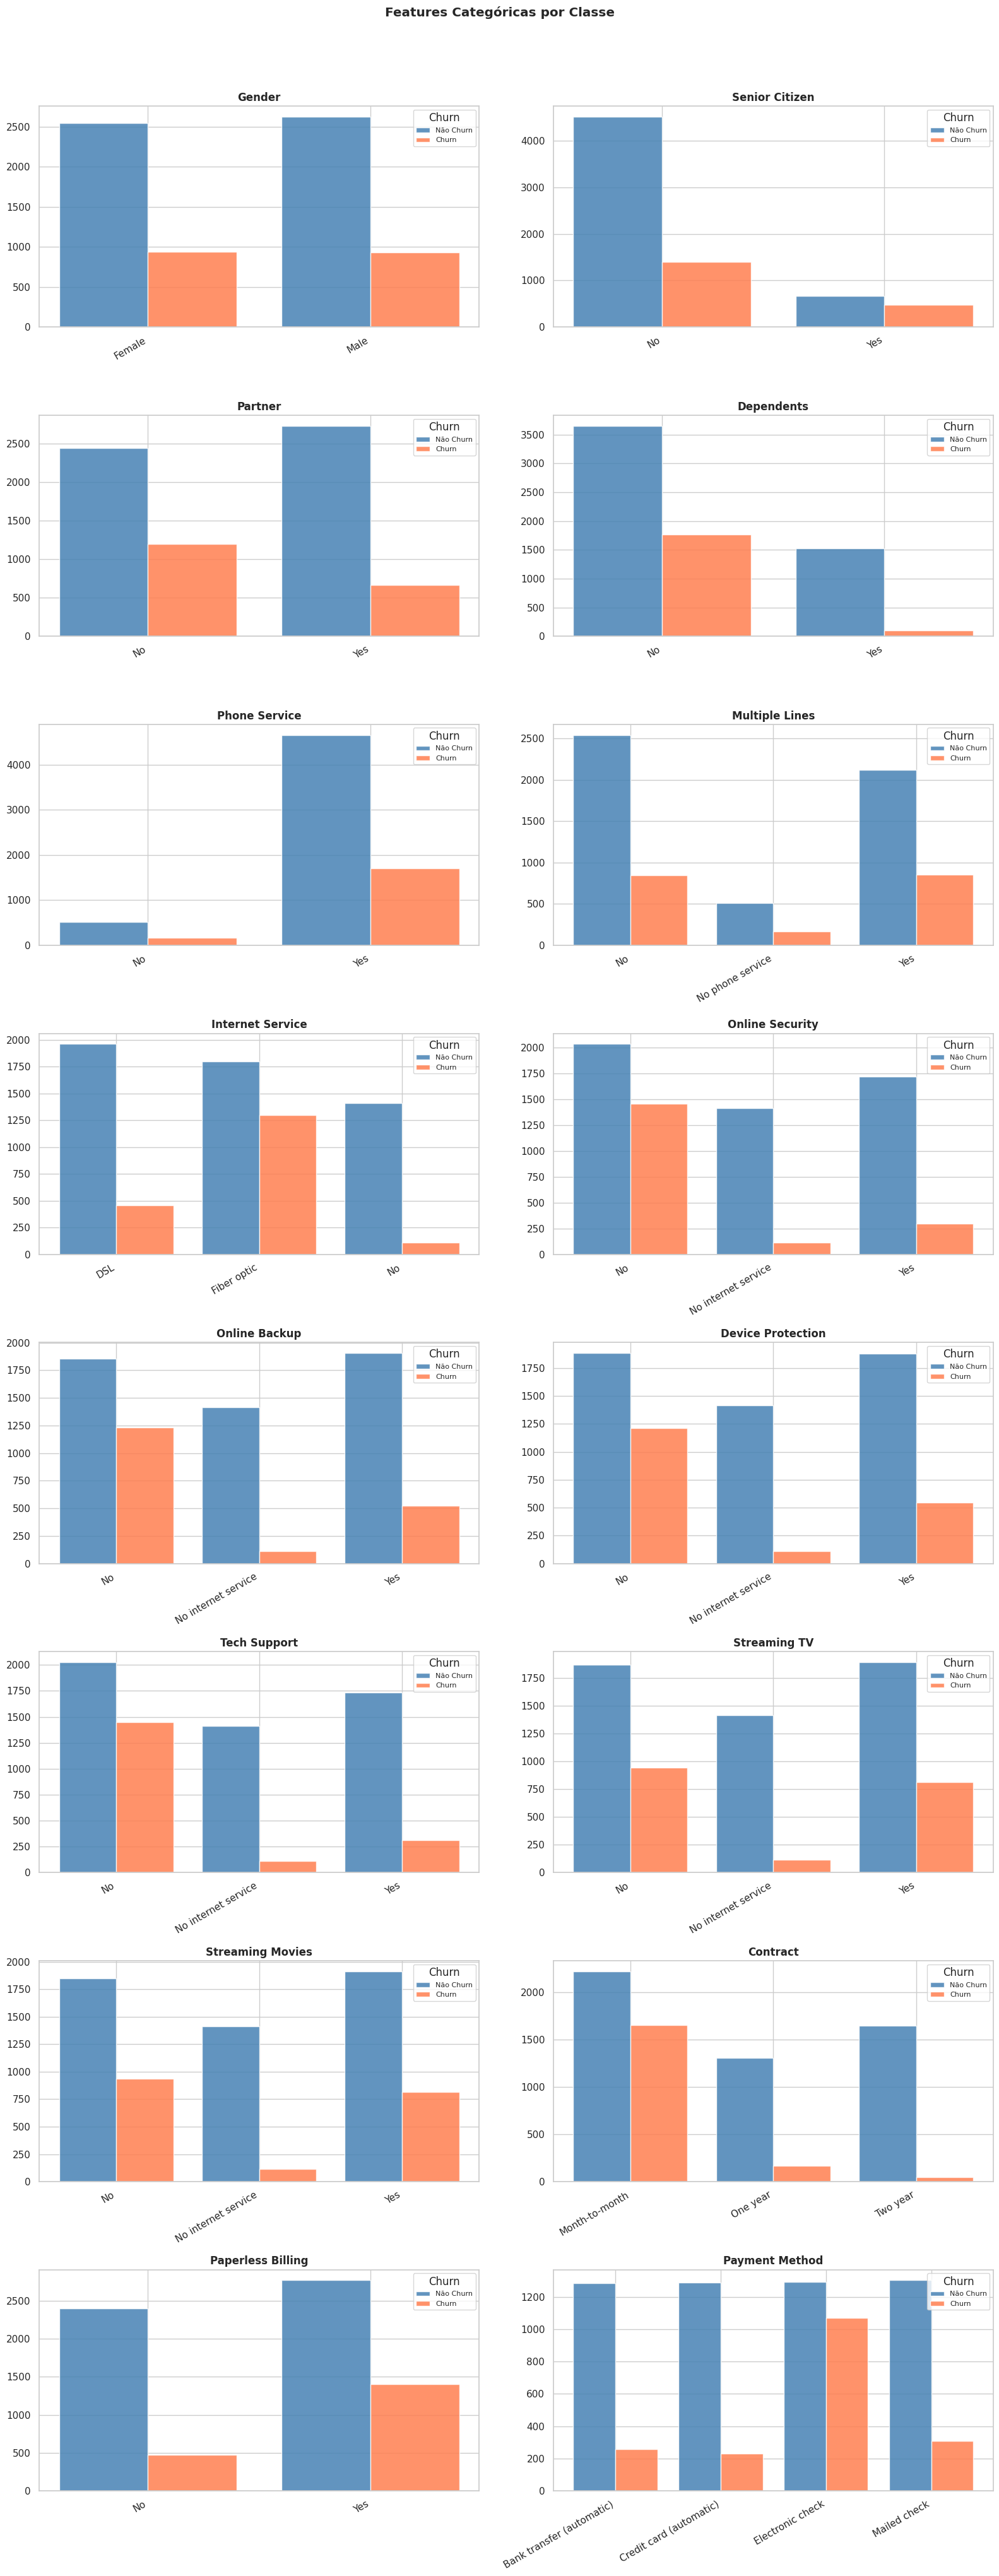

In [18]:
# Countplots por classe
plot_cat_cols = [c for c in cat_cols if df[c].nunique() <= MAX_CAT_CARDINALITY]
high_card = [c for c in cat_cols if c not in plot_cat_cols]

if high_card:
    print(f"Colunas omitidas (cardinalidade > {MAX_CAT_CARDINALITY}): {high_card}")

n = len(plot_cat_cols)
ncols = min(2, n)
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 5 * nrows))
axes = np.array(axes).ravel()

for i, col in enumerate(plot_cat_cols):
    crosstab = pd.crosstab(df[col], df[TARGET_COL])
    categories = crosstab.index.tolist()
    classes = crosstab.columns.tolist()
    x = np.arange(len(categories))
    width = 0.8 / len(classes)

    for j, cls in enumerate(classes):
        offset = (j - (len(classes) - 1) / 2) * width
        axes[i].bar(
            x + offset, crosstab[cls], width,
            label=CLASS_LABELS.get(cls, str(cls)),
            color=CLASS_COLORS.get(cls, 'grey'),
            edgecolor='white', alpha=0.85
        )

    axes[i].set_xticks(x)
    axes[i].set_xticklabels(categories, rotation=30, ha='right')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(title='Churn', fontsize=8)

for ax in axes[n:]:
    fig.delaxes(ax)

plt.suptitle('Features Categóricas por Classe', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Taxa de churn por categoria
print("Taxa de Churn (%) por variável categórica:\n")
for col in plot_cat_cols:
    churn_rate = (
        df.groupby(col)[TARGET_COL]
        .mean()
        .mul(100)
        .round(1)
        .sort_values(ascending=False)
        .rename('Churn (%)')
    )
    counts_col = df[col].value_counts().rename('n')
    summary = pd.concat([churn_rate, counts_col], axis=1)
    print(f"--- {col} ---")
    print(summary.to_string())
    print()

Taxa de Churn (%) por variável categórica:

--- Gender ---
        Churn (%)     n
Gender                 
Female       26.9  3488
Male         26.2  3555

--- Senior Citizen ---
                Churn (%)     n
Senior Citizen                 
Yes                  41.7  1142
No                   23.6  5901

--- Partner ---
         Churn (%)     n
Partner                 
No            33.0  3641
Yes           19.7  3402

--- Dependents ---
            Churn (%)     n
Dependents                 
No               32.6  5416
Yes               6.5  1627

--- Phone Service ---
               Churn (%)     n
Phone Service                 
Yes                 26.7  6361
No                  24.9   682

--- Multiple Lines ---
                  Churn (%)     n
Multiple Lines                   
Yes                    28.6  2971
No                     25.0  3390
No phone service       24.9   682

--- Internet Service ---
                  Churn (%)     n
Internet Service                 
Fiber opt

In [20]:
insights.extend([
    {
        'secao': 'Features Categóricas',
        'insight': 'Contract: Month-to-month → 42.7% churn vs Two year → 2.8% (diferença de ~15x)',
        'impacto_modelo': 'Feature de maior poder discriminativo identificada na EDA — provável top feature de importância',
        'acao_sugerida': 'Manter; considerar engenharia: variável binária "contrato_longo" (one year + two year = 0)',
    },
    {
        'secao': 'Features Categóricas',
        'insight': 'Payment Method: Electronic check → 45.3% churn vs automáticos (cartão/transferência) → ~15-16%',
        'impacto_modelo': 'Clientes que pagam via boleto eletrônico têm perfil de maior evasão — proxy de engajamento',
        'acao_sugerida': 'Manter; considerar agrupar métodos automáticos em categoria única',
    },
    {
        'secao': 'Features Categóricas',
        'insight': 'Internet Service: Fiber optic → 41.9% churn vs DSL 19.0% vs Sem internet 7.4%',
        'impacto_modelo': 'Possível insatisfação com qualidade do serviço de fibra — feature relevante',
        'acao_sugerida': 'Manter; investigar se preço da fibra correlaciona com Monthly Charges alto',
    },
    {
        'secao': 'Features Categóricas',
        'insight': 'Add-ons (Online Security, Tech Support, Online Backup, Device Protection): sem serviço ~39-42% churn; com serviço ~14-22%',
        'impacto_modelo': 'Add-ons funcionam como âncoras de retenção — cliente engajado com mais serviços cancela menos',
        'acao_sugerida': 'Manter todas; considerar feature agregada "qtd_addons" como contagem de serviços ativos',
    },
    {
        'secao': 'Features Categóricas',
        'insight': 'Senior Citizen: idosos → 41.7% churn vs não-idosos → 23.6% (1.77x)',
        'impacto_modelo': 'Segmento de risco elevado — relevante para estratégia de retenção direcionada',
        'acao_sugerida': 'Manter como feature; pode ser usada para segmentar ações de retenção',
    },
    {
        'secao': 'Features Categóricas',
        'insight': 'Dependents: sem dependentes → 32.6% churn vs com dependentes → 6.5% (5x)',
        'impacto_modelo': 'Clientes com família são fortemente mais fiéis — feature com alta separação',
        'acao_sugerida': 'Manter; junto com Partner (19.7% vs 33.0%) forma perfil demográfico de risco',
    },
    {
        'secao': 'Features Categóricas',
        'insight': 'Gender: Male 26.2% vs Female 26.9% — diferença de apenas 0.7 pp',
        'impacto_modelo': 'Feature provavelmente irrelevante para o modelo — não há separação entre classes',
        'acao_sugerida': 'Candidata a remoção; confirmar com feature importance após treino do baseline',
    },
])

## Correlações

Identificação de correlações entre as features.

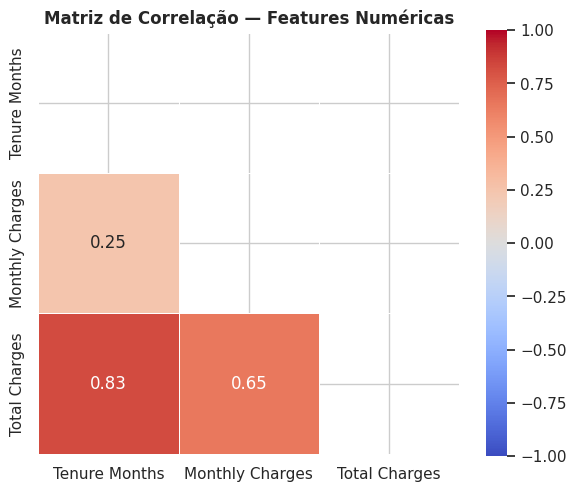

In [21]:
# Heatmap de correlação (triângulo inferior)
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

size = max(6, len(num_cols))
plt.figure(figsize=(size, size - 1))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1,
    linewidths=0.5, square=True
)
plt.title('Matriz de Correlação — Features Numéricas', fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# Pares com alta correlação (possível multicolinearidade)
THRESHOLD = 0.7
high_corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) >= THRESHOLD:
            high_corr_pairs.append({
                'Feature A': corr.columns[i],
                'Feature B': corr.columns[j],
                'Correlação': round(val, 3),
            })

if high_corr_pairs:
    result = (
        pd.DataFrame(high_corr_pairs)
        .sort_values('Correlação', key=abs, ascending=False)
    )
    print(f"Pares com |correlação| ≥ {THRESHOLD}:")
    print(result.to_string(index=False))
else:
    print(f"Nenhum par com |correlação| ≥ {THRESHOLD} encontrado.")

Pares com |correlação| ≥ 0.7:
    Feature A     Feature B  Correlação
Tenure Months Total Charges       0.826


In [23]:
insights.extend([
    {
        'secao': 'Correlações',
        'insight': 'Tenure Months × Total Charges: correlação de 0.826 — multicolinearidade alta',
        'impacto_modelo': 'Em modelos lineares, coeficientes ficam instáveis; em árvores o impacto é menor mas há redundância',
        'acao_sugerida': 'Considerar remover Total Charges ou aplicar PCA; monitorar feature importance no baseline',
    },
])

## Análises Complementares (Gap Fix da EDA)

Análises adicionais que estavam ausentes na versão anterior e que podem impactar diretamente a modelagem. Cada bloco explica o achado e a ação recomendada.

### Duplicatas

Verificação de linhas idênticas (excluindo CustomerID) — duplicatas silenciosas inflam métricas e viciam splits.

In [24]:
dup_full = df.duplicated().sum()
dup_no_id = df.drop(columns=['CustomerID']).duplicated().sum()
print(f'Duplicatas exatas         : {dup_full}')
print(f'Duplicatas (sem CustomerID): {dup_no_id}')

Duplicatas exatas         : 0
Duplicatas (sem CustomerID): 0


### Investigação: Tenure = 0 e Total Charges NaN

Hipótese: os 11 NaNs em `Total Charges` correspondem a clientes recém-chegados que ainda não faturaram. Se confirmado, **imputar com a mediana (~1.397) distorce o significado da variável** — o correto é imputar com 0.

In [25]:
nan_tc = df[df['Total Charges'].isna()]
print(f'Registros com Total Charges NaN: {len(nan_tc)}')
print(f'  Tenure Months únicos: {sorted(nan_tc["Tenure Months"].unique())}')
print(f'  Distribuição de Churn: {nan_tc["Churn Value"].value_counts().to_dict()}')
print(f'  Monthly Charges (média): {nan_tc["Monthly Charges"].mean():.2f}')
print()
print('Conclusão: 100% dos NaNs são Tenure=0 e Churn=0 → clientes recém-cadastrados.')
print('Impute correto no pipeline: 0 (não pagou ainda) — não a mediana.')

Registros com Total Charges NaN: 11
  Tenure Months únicos: [np.int64(0)]
  Distribuição de Churn: {0: 11}
  Monthly Charges (média): 41.42

Conclusão: 100% dos NaNs são Tenure=0 e Churn=0 → clientes recém-cadastrados.
Impute correto no pipeline: 0 (não pagou ainda) — não a mediana.


### Redundância entre Features Categóricas

As 6 features de add-ons (`Online Security`, `Online Backup`, `Device Protection`, `Tech Support`, `Streaming TV`, `Streaming Movies`) usam o valor `'No internet service'` para representar clientes sem internet.

Este valor é **100% determinado** por `Internet Service == 'No'`. O mesmo padrão ocorre em `Multiple Lines == 'No phone service'` ↔ `Phone Service == 'No'`. Após OneHotEncoder isso gera **7 colunas binárias perfeitamente colineares** — infla a dimensionalidade e prejudica modelos lineares.

In [26]:
addons = ['Online Security','Online Backup','Device Protection',
          'Tech Support','Streaming TV','Streaming Movies']

print('Add-on: quantos são "No internet service" e se batem 1:1 com Internet Service=="No"')
for c in addons:
    n = (df[c] == 'No internet service').sum()
    match = ((df[c] == 'No internet service') == (df['Internet Service'] == 'No')).all()
    print(f'  {c:20s}  n={n:4d}   colinear={match}')

n_ml = (df['Multiple Lines'] == 'No phone service').sum()
match_ml = ((df['Multiple Lines'] == 'No phone service') == (df['Phone Service'] == 'No')).all()
print(f'  Multiple Lines (No phone service)  n={n_ml:4d}   colinear={match_ml}')

print()
print('Ação: colapsar "No internet service" → "No" e "No phone service" → "No"')
print('      Reduz 7 categorias binárias colineares após OHE, sem perda de informação.')

Add-on: quantos são "No internet service" e se batem 1:1 com Internet Service=="No"
  Online Security       n=1526   colinear=True
  Online Backup         n=1526   colinear=True
  Device Protection     n=1526   colinear=True
  Tech Support          n=1526   colinear=True
  Streaming TV          n=1526   colinear=True
  Streaming Movies      n=1526   colinear=True
  Multiple Lines (No phone service)  n= 682   colinear=True

Ação: colapsar "No internet service" → "No" e "No phone service" → "No"
      Reduz 7 categorias binárias colineares após OHE, sem perda de informação.


### Associação Estatística Categóricas × Target (Cramér's V)

A EDA anterior mediu "taxa de churn por categoria" mas não quantificou a **força de associação**. Cramér's V (0 = independente, 1 = perfeita) permite ranquear features categóricas objetivamente e identificar candidatas a remoção.

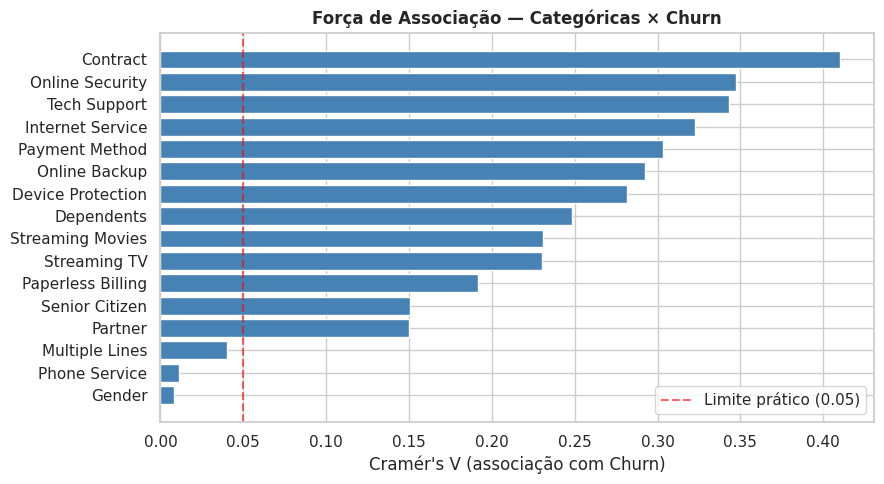

          Feature  Cramers_V
         Contract   0.410116
  Online Security   0.347400
     Tech Support   0.342916
 Internet Service   0.322455
   Payment Method   0.303359
    Online Backup   0.292316
Device Protection   0.281580
       Dependents   0.248161
 Streaming Movies   0.230951
     Streaming TV   0.230502
Paperless Billing   0.191498
   Senior Citizen   0.150453
          Partner   0.150126
   Multiple Lines   0.040109
    Phone Service   0.011398
           Gender   0.008291


In [27]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cv_rows = [(c, cramers_v(df[c], df[TARGET_COL])) for c in cat_cols]
cv_df = pd.DataFrame(cv_rows, columns=['Feature', 'Cramers_V']).sort_values('Cramers_V', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(cv_df['Feature'][::-1], cv_df['Cramers_V'][::-1], color='steelblue', edgecolor='white')
ax.axvline(0.05, color='red', ls='--', alpha=0.6, label='Limite prático (0.05)')
ax.set_xlabel("Cramér's V (associação com Churn)")
ax.set_title('Força de Associação — Categóricas × Churn', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

print(cv_df.to_string(index=False))

### Correlação Numéricas × Target (Point-biserial)

Correlação de Pearson entre feature numérica e target binário (equivalente a point-biserial) — quantifica separabilidade.

In [28]:
pb_rows = []
for c in num_cols:
    r = df[[c, TARGET_COL]].corr().iloc[0, 1]
    pb_rows.append({'Feature': c, 'Correlação c/ Churn': round(r, 4)})
pd.DataFrame(pb_rows)

,Feature,Correlação c/ Churn
0,Tenure Months,-0.3522
1,Monthly Charges,0.1934
2,Total Charges,-0.1995


### Churn por Faixa de Tenure

Distribuição do churn em bins de tempo de contrato revela que **clientes 0-3 meses churnaram em 56%** — um fator de risco ordens de magnitude maior que qualquer outra feature isolada. Justifica criar a feature derivada `novo_cliente`.

             Churn rate     n
_tenure_bin                  
0-3 (novo)        0.562  1062
4-12              0.391  1124
13-24             0.287  1024
25-48             0.204  1594
49-72             0.095  2239


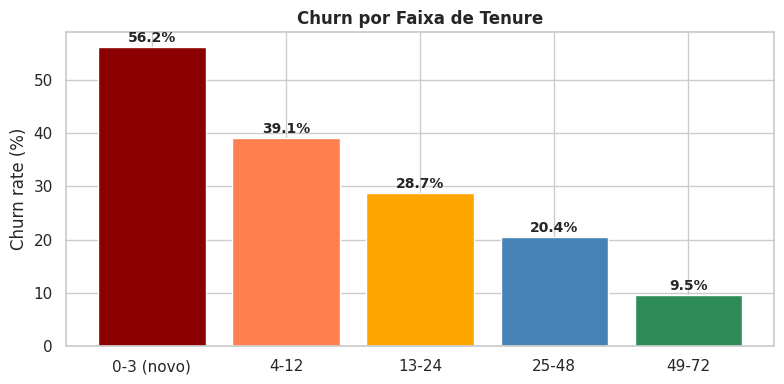

In [29]:
bins = [-1, 3, 12, 24, 48, 72]
labels = ['0-3 (novo)', '4-12', '13-24', '25-48', '49-72']
df['_tenure_bin'] = pd.cut(df['Tenure Months'], bins=bins, labels=labels)

tenure_summary = (df.groupby('_tenure_bin', observed=True)[TARGET_COL]
                    .agg(['mean', 'count']).round(3))
tenure_summary.columns = ['Churn rate', 'n']
print(tenure_summary)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(tenure_summary.index.astype(str), tenure_summary['Churn rate']*100,
       color=['darkred','coral','orange','steelblue','seagreen'], edgecolor='white')
for i, v in enumerate(tenure_summary['Churn rate']*100):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Churn rate (%)'); ax.set_title('Churn por Faixa de Tenure', fontweight='bold')
plt.tight_layout(); plt.show()

df.drop(columns=['_tenure_bin'], inplace=True)

### Distribuição de `Monthly Charges` — Bimodalidade

`Monthly Charges` apresenta clara bimodalidade: pico em torno de \$20 (planos básicos sem internet) e cauda densa acima de \$70 (planos com fibra). Confirma que o segmento de tarifa alta domina o dataset e concentra risco.

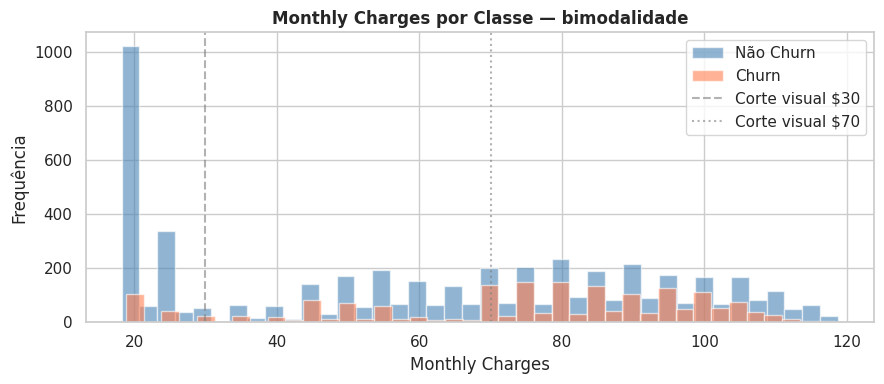

  $  0-$30 : n= 1653  churn=9.8%
  $ 30-$70 : n= 1799  churn=24.1%
  $ 70-$150: n= 3591  churn=35.5%


In [30]:
fig, ax = plt.subplots(figsize=(9, 4))
for val, grp in df.groupby(TARGET_COL):
    ax.hist(grp['Monthly Charges'], bins=40, alpha=0.6,
            label=CLASS_LABELS[val], color=CLASS_COLORS[val])
ax.axvline(30, color='gray', ls='--', alpha=0.6, label='Corte visual $30')
ax.axvline(70, color='gray', ls=':',  alpha=0.6, label='Corte visual $70')
ax.set_xlabel('Monthly Charges'); ax.set_ylabel('Frequência')
ax.set_title('Monthly Charges por Classe — bimodalidade', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

for lo, hi in [(0,30),(30,70),(70,150)]:
    mask = (df['Monthly Charges']>=lo)&(df['Monthly Charges']<hi)
    print(f'  ${lo:>3d}-${hi:<3d}: n={mask.sum():5d}  churn={df[mask][TARGET_COL].mean()*100:.1f}%')

### Interação Contract × Tenure

O contrato é o preditor mais forte (Cramér's V = 0,41) e Tenure é o numérico mais forte. Verificar se o efeito combinado potencializa ou anula sinais individuais.

Churn rate — Contract × Faixa de Tenure
Contract       Month-to-month  One year  Two year
Tenure Months                                    
(-1, 12]                0.514     0.105     0.000
(12, 24]                0.377     0.081     0.000
(24, 48]                0.329     0.106     0.022
(48, 72]                0.260     0.129     0.033


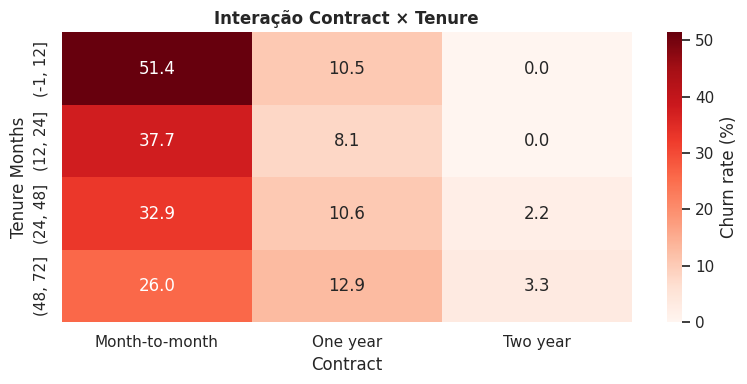

In [31]:
pivot = df.pivot_table(index=pd.cut(df['Tenure Months'], bins=[-1,12,24,48,72]),
                        columns='Contract', values=TARGET_COL,
                        aggfunc='mean', observed=True).round(3)
print('Churn rate — Contract × Faixa de Tenure')
print(pivot)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot*100, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label':'Churn rate (%)'}, ax=ax)
ax.set_title('Interação Contract × Tenure', fontweight='bold')
plt.tight_layout(); plt.show()

In [32]:
insights.extend([
    {'secao': 'Qualidade dos Dados',
     'insight': 'Total Charges NaN (n=11) 100% correspondem a Tenure=0 e Churn=0 — clientes recém-cadastrados',
     'impacto_modelo': 'Imputar com mediana (~1.397) distorce semântica; o valor correto é 0',
     'acao_sugerida': 'No pipeline: preencher Total Charges com 0 quando Tenure=0 (regra) antes do imputer'},
    {'secao': 'Qualidade dos Dados',
     'insight': 'Duplicatas exatas ou por conteúdo (sem CustomerID): 0 — dataset limpo',
     'impacto_modelo': 'Sem risco de leakage por linhas repetidas entre train/test',
     'acao_sugerida': 'Nenhuma ação necessária'},
    {'secao': 'Redundância',
     'insight': '6 add-ons têm categoria "No internet service" 100% colinear com Internet Service=="No" (n=1526 cada)',
     'impacto_modelo': 'Gera 6 colunas OHE perfeitamente colineares; degrada LogReg e infla dimensionalidade',
     'acao_sugerida': 'Colapsar "No internet service" → "No" nos 6 add-ons antes do OHE'},
    {'secao': 'Redundância',
     'insight': 'Multiple Lines "No phone service" 100% colinear com Phone Service=="No" (n=682)',
     'impacto_modelo': 'Mesma dinâmica: coluna OHE redundante',
     'acao_sugerida': 'Colapsar "No phone service" → "No" em Multiple Lines'},
    {'secao': 'Associação Categórica',
     'insight': "Cramér's V: Gender=0.008, Phone Service=0.011, Multiple Lines=0.040 — associação com churn praticamente nula",
     'impacto_modelo': 'Ruído puro — só adicionam dimensionalidade e risco de overfitting sutil',
     'acao_sugerida': 'Remover Gender e Phone Service; manter Multiple Lines por enquanto (0.04 é marginal)'},
    {'secao': 'Associação Categórica',
     'insight': "Cramér's V (top): Contract=0.41, Online Security=0.35, Tech Support=0.34, Internet Service=0.32",
     'impacto_modelo': 'Ranking objetivo dos preditores categóricos — coerente com feature importance esperada',
     'acao_sugerida': 'Manter todas; validar contra feature importance pós-treino'},
    {'secao': 'Features Numéricas',
     'insight': 'Tenure 0-3 meses tem 56% de churn (vs 9.5% em 49-72 meses)',
     'impacto_modelo': 'Sinal muito forte no início do ciclo — captado apenas parcialmente por Tenure linear',
     'acao_sugerida': "Criar feature 'novo_cliente' = (Tenure <= 3) para modelos lineares capturarem o degrau"},
    {'secao': 'Features Numéricas',
     'insight': 'Monthly Charges é bimodal: pico ~\$20 (planos básicos, churn ~11%) e >\$70 (planos com fibra, churn ~34%)',
     'impacto_modelo': 'Relação não-linear parcialmente captada por árvores; LogReg pode se beneficiar de binning',
     'acao_sugerida': 'Manter contínua; considerar bin categórico (low/mid/high) em iterações futuras'},
    {'secao': 'Interações',
     'insight': 'Contract × Tenure: mesmo Month-to-month cai de ~60% para ~20% de churn conforme tenure cresce',
     'impacto_modelo': 'Interação não-linear — modelos de árvore capturam nativamente, LogReg precisa de feature explícita',
     'acao_sugerida': 'Considerar feature de interação (ex.: contrato_longo * tenure) se GB/RF vencerem por larga margem'},
])

<>:31: SyntaxWarning: invalid escape sequence '\$'
<>:31: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_33512/155469390.py:31: SyntaxWarning: invalid escape sequence '\$'
  'insight': 'Monthly Charges é bimodal: pico ~\$20 (planos básicos, churn ~11%) e >\$70 (planos com fibra, churn ~34%)',


## Consolidação dos Insights da EDA

Pontos identificados ao longo da análise exploratória que impactam a modelagem ou geram insights de negócio.

In [33]:
df_insights = (
    pd.DataFrame(insights)
    .reset_index(drop=True)
)
df_insights.index += 1
df_insights.columns = ['Seção', 'Insight', 'Impacto no Modelo', 'Ação Sugerida']

pd.set_option('display.max_colwidth', None)
df_insights

,Seção,Insight,Impacto no Modelo,Ação Sugerida
1,Qualidade dos Dados,Total Charges com dtype incorreto (object): 11 valores em branco convertidos para NaN após pd.to_numeric(),NaNs precisam de imputação antes do treinamento para evitar erro no sklearn,"Aplicar SimpleImputer(strategy=""median"") no pipeline de pré-processamento"
2,Qualidade dos Dados,Churn Reason tem 73.5% de valores nulos (5.174 de 7.043 registros),Coluna de leakage (motivo só existe após o churn) — não pode ser usada como feature,Manter excluída de EXCLUDE_COLS; pode ser útil para análise de negócio pós-predição
3,Qualidade dos Dados,Dataset final com 3 features numéricas e 16 categóricas após exclusão de metadados/leakage,Dominância categórica exige encoding adequado (OneHotEncoder) e atenção à dimensionalidade,Usar ColumnTransformer separando pipelines para numéricas e categóricas
4,Variável Target,Desbalanceamento: 26.5% churn (1.869) vs 73.5% não churn (5.174) — ratio 0.361,"Modelo trivial que prevê sempre ""Não Churn"" atingiria 73.5% de acurácia sem aprender nada","Usar class_weight=""balanced"" ou SMOTE; avaliar com AUC-ROC e F1 (classe churn)"
5,Features Numéricas,Tenure Months: churners concentram-se em valores baixos (0-20 meses); não-churners distribuídos uniformemente até 72,Feature com alta separabilidade entre classes — provável alta importância no modelo,Manter; aplicar StandardScaler no pipeline
6,Features Numéricas,Monthly Charges: churners têm cobranças mensais sistematicamente mais altas,Feature discriminativa — clientes com planos mais caros cancelam mais,Manter; pode gerar feature combinada com Tenure (ex.: Total Charges estimado)
7,Features Numéricas,Total Charges tem 11 NaNs após conversão de tipo (valores em branco no CSV original),NaNs causarão erro em modelos sklearn sem tratamento prévio,Imputar com mediana no pipeline; não usar mode/mean pois distribuição é assimétrica
8,Features Categóricas,Contract: Month-to-month → 42.7% churn vs Two year → 2.8% (diferença de ~15x),Feature de maior poder discriminativo identificada na EDA — provável top feature de importância,"Manter; considerar engenharia: variável binária ""contrato_longo"" (one year + two year = 0)"
9,Features Categóricas,Payment Method: Electronic check → 45.3% churn vs automáticos (cartão/transferência) → ~15-16%,Clientes que pagam via boleto eletrônico têm perfil de maior evasão — proxy de engajamento,Manter; considerar agrupar métodos automáticos em categoria única
10,Features Categóricas,Internet Service: Fiber optic → 41.9% churn vs DSL 19.0% vs Sem internet 7.4%,Possível insatisfação com qualidade do serviço de fibra — feature relevante,Manter; investigar se preço da fibra correlaciona com Monthly Charges alto


## Definição de Métricas

Definição das métricas técnicas e de negócio que serão utilizadas para avaliar a performance do modelo preditivo de churn.

### Critério de Escolha

O ponto de partida é o **custo assimétrico dos erros** neste problema:

| Erro | Consequência | Custo |
|---|---|---|
| **Falso Negativo** (churner não detectado) | Cliente cancela sem oferta de retenção | Alto — receita perdida |
| **Falso Positivo** (não-churner abordado) | Oferta desnecessária | Baixo — custo da ação |

Como o custo do Falso Negativo domina, priorizamos métricas que penalizam miss de churners reais.

### Métricas Selecionadas

| Tipo | Métrica | Justificativa |
|---|---|---|
| **Técnica principal** | AUC-ROC | Avalia o poder de ranking do modelo independente do threshold. Padrão da indústria para classificação binária desbalanceada. |
| **Técnica secundária** | F1-Score (classe churn) | Equilíbrio entre Precision e Recall — útil quando falso negativo tem custo alto. |
| **Negócio** | Recall (classe churn) | "De todos os clientes que vão cancelar, quantos identificamos?" Maximizar esse número maximiza oportunidades de retenção. |

> **Por que não acurácia?** Com 73.5% de não-churners, um modelo trivial que sempre prevê "Não Churn" atinge 73.5% de acurácia sem aprender nada.

## Feature Cleaning — Correções pós-EDA

Aplicação das ações derivadas dos insights:

1. **Fix imputação:** `Total Charges = 0` quando `Tenure Months = 0` (11 clientes recém-cadastrados) — evita distorcer com mediana ~1.397.
2. **Colinearidade:** `"No internet service"` → `"No"` nos 6 add-ons e `"No phone service"` → `"No"` em Multiple Lines — elimina 7 colunas OHE redundantes.
3. **Drop irrelevantes:** remove `Gender` (Cramér's V=0,008) e `Phone Service` (0,011) — ruído puro.

In [34]:
DROP_LOW_ASSOC = ['Gender', 'Phone Service']  # Cramér's V < 0.02

def clean_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # 1) Fix Total Charges quando Tenure=0 (recém-cadastrado, ainda não pagou)
    mask_new = (df['Tenure Months'] == 0) & (df['Total Charges'].isna())
    df.loc[mask_new, 'Total Charges'] = 0.0

    # 2) Colapsar categorias colineares 'No internet service' e 'No phone service'
    addons = ['Online Security','Online Backup','Device Protection',
              'Tech Support','Streaming TV','Streaming Movies']
    for c in addons:
        df[c] = df[c].replace('No internet service', 'No')
    df['Multiple Lines'] = df['Multiple Lines'].replace('No phone service', 'No')

    # 3) Drop features de baixíssima associação com o target
    df = df.drop(columns=[c for c in DROP_LOW_ASSOC if c in df.columns])
    return df

df = clean_features(df)

# Recalcular colunas derivadas após a limpeza
feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS + [TARGET_COL]]
num_cols = df[feature_cols].select_dtypes(include='number').columns.tolist()
cat_cols = [c for c in feature_cols if c not in num_cols]
print(f'Após limpeza: {len(feature_cols)} features ({len(num_cols)} num + {len(cat_cols)} cat)')
print(f'  Removidas: {DROP_LOW_ASSOC}')
print(f'  NaNs restantes em Total Charges: {df["Total Charges"].isna().sum()}')

insights.append({
    'secao': 'Feature Cleaning',
    'insight': 'Limpeza aplicada: fix TC=0 para 11 clientes novos + colapso de 7 categorias colineares + drop de Gender/Phone Service',
    'impacto_modelo': 'Reduz dimensionalidade pós-OHE em ~9 colunas e elimina distorção de imputação',
    'acao_sugerida': 'Aplicado antes do pré-processamento do baseline'
})

Após limpeza: 17 features (3 num + 14 cat)
  Removidas: ['Gender', 'Phone Service']
  NaNs restantes em Total Charges: 0


## Pré-processamento Inicial

Preparação dos dados para entrada no pipeline de modelagem: remoção de identificadores, separação de features e target, e divisão estratificada treino/teste.

In [35]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.2

# Colunas de features: excluir metadados/leakage e o target
feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS + [TARGET_COL]]

X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

# Derivar listas de colunas para o ColumnTransformer
num_features = X.select_dtypes(include='number').columns.tolist()
cat_features = [c for c in X.columns
                if isinstance(X[c].dtype, pd.StringDtype) or X[c].dtype == object]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Treino : {X_train.shape[0]:,} amostras  ({y_train.mean()*100:.1f}% churn)")
print(f"Teste  : {X_test.shape[0]:,} amostras  ({y_test.mean()*100:.1f}% churn)")
print(f"\nFeatures numéricas  ({len(num_features)}): {num_features}")
print(f"Features categóricas ({len(cat_features)}): {cat_features}")

Treino : 5,634 amostras  (26.5% churn)
Teste  : 1,409 amostras  (26.5% churn)

Features numéricas  (3): ['Tenure Months', 'Monthly Charges', 'Total Charges']
Features categóricas (14): ['Senior Citizen', 'Partner', 'Dependents', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


## Pipeline de Pré-processamento com Scikit-Learn

`ColumnTransformer` que aplica transformações distintas para features numéricas e categóricas, garantindo que o mesmo processo é usado no treino, teste e produção sem data leakage.

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
], remainder='drop')

print("Preprocessor configurado:")
print(f"  Numéricas ({len(num_features)}): SimpleImputer(median) → StandardScaler")
print(f"  Categóricas ({len(cat_features)}): SimpleImputer(most_frequent) → OneHotEncoder")

Preprocessor configurado:
  Numéricas (3): SimpleImputer(median) → StandardScaler
  Categóricas (14): SimpleImputer(most_frequent) → OneHotEncoder


## Modelo Baseline: Regressão Logística

Baseline com `LogisticRegression` encapsulado no pipeline completo. A Regressão Logística serve como piso de performance: qualquer modelo mais complexo precisa superar esses números para justificar sua complexidade.

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                              RocCurveDisplay, ConfusionMatrixDisplay)
import joblib
import os

# Pipeline completo: pré-processamento + classificador
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE,
        class_weight='balanced',
    )),
])

pipeline.fit(X_train, y_train)
print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


In [38]:
# Avaliação no conjunto de teste
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)

print(f"AUC-ROC: {auc:.4f}\n")
print("=== Classification Report (classe churn = 1) ===")
print(classification_report(y_test, y_pred,
                             target_names=['Não Churn', 'Churn']))

AUC-ROC: 0.8487

=== Classification Report (classe churn = 1) ===
              precision    recall  f1-score   support

   Não Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



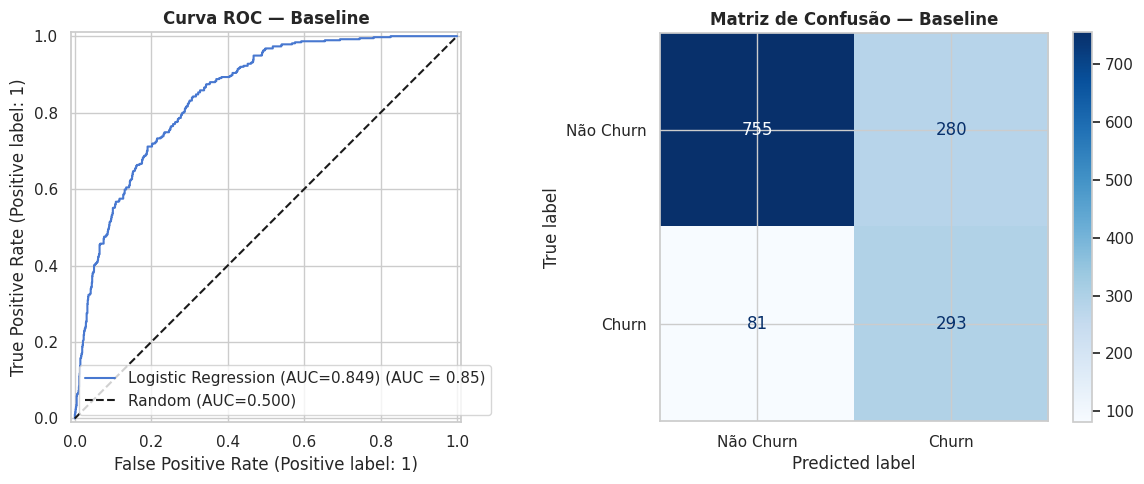

In [39]:
# Curva ROC + Matriz de Confusão
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_test, y_proba,
    name=f'Logistic Regression (AUC={auc:.3f})',
    ax=axes[0],
)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.500)')
axes[0].set_title('Curva ROC — Baseline', fontweight='bold')
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Não Churn', 'Churn'],
    cmap='Blues', ax=axes[1],
)
axes[1].set_title('Matriz de Confusão — Baseline', fontweight='bold')

plt.tight_layout()
plt.show()

In [40]:
# Salvar o modelo baseline
MODEL_PATH = '../models/baseline_logistic_regression.joblib'
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
joblib.dump(pipeline, MODEL_PATH)
print(f"Modelo salvo em: {MODEL_PATH}")

Modelo salvo em: ../models/baseline_logistic_regression.joblib
